<a href="https://colab.research.google.com/github/saicharanmangalagiri2006-svg/pico/blob/main/t-2%20testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import kagglehub
path = kagglehub.dataset_download("imtkaggleteam/air-traffic-landings")

Using Colab cache for faster access to the 'air-traffic-landings' dataset.


In [41]:
import pandas as pd
import os

# Assuming the 'path' variable is available from previous steps
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV files found in the downloaded directory. Please ensure the 'path' variable is correctly set and the dataset is downloaded.")

data_file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(data_file_path)

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
0,201809,SkyWest Airlines,OO,United Airlines,UA,International,Canada,Passenger,Regional Jet,Bombardier,CRJ2,-,30,1410000
1,201809,Air Canada,AC,Air Canada,AC,International,Canada,Passenger,Narrow Body,Airbus,A320,-,125,17787978
2,201809,Japan Airlines,JL,Japan Airlines,JL,International,Asia,Passenger,Wide Body,Boeing,B773,-,30,16620000
3,201809,"COPA Airlines, Inc.",CM,"COPA Airlines, Inc.",CM,International,Central America,Passenger,Narrow Body,Boeing,B739,-,3,491700
4,201809,Hong Kong Airlines Limited,HX,Hong Kong Airlines Limited,HX,International,Asia,Passenger,Wide Body,Airbus,A359,-,16,7301712


In [42]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import files

print("\nDataFrame Info (data types and non-null counts):")
df.info()

print("\nMissing values count:")
display(df.isnull().sum()[df.isnull().sum() > 0])


DataFrame Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22047 entries, 0 to 22046
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              22047 non-null  int64 
 1   Operating Airline            22047 non-null  object
 2   Operating Airline IATA Code  21972 non-null  object
 3   Published Airline            22047 non-null  object
 4   Published Airline IATA Code  21972 non-null  object
 5   GEO Summary                  22047 non-null  object
 6   GEO Region                   22047 non-null  object
 7   Landing Aircraft Type        22047 non-null  object
 8   Aircraft Body Type           22047 non-null  object
 9   Aircraft Manufacturer        22036 non-null  object
 10  Aircraft Model               22047 non-null  object
 11  Aircraft Version             20889 non-null  object
 12  Landing Count                22047 non

,0
Operating Airline IATA Code,75
Published Airline IATA Code,75
Aircraft Manufacturer,11
Aircraft Version,1158


### 2. Automatically handle missing values

We will impute numerical columns with their median and categorical columns with their mode.

In [43]:
# Separate numerical and categorical columns for imputation
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Impute numerical columns with median
if len(numerical_cols) > 0:
    numerical_imputer = SimpleImputer(strategy='median')
    df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])
    print("Numerical columns imputed with median.")
else:
    print("No numerical columns to impute.")

# Impute categorical columns with mode
if len(categorical_cols) > 0:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    # Use .copy() to avoid SettingWithCopyWarning if df is a slice
    df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])
    print("Categorical columns imputed with mode.")
else:
    print("No categorical columns to impute.")

print("\nMissing values after imputation:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Numerical columns imputed with median.
Categorical columns imputed with mode.

Missing values after imputation:


,0


### 3. Encode categorical string columns into numerical values

In [44]:
# Identify categorical columns that are still objects (strings) after imputation
categorical_string_cols = df.select_dtypes(include=['object']).columns

print(f"Categorical columns to encode: {list(categorical_string_cols)}")

for col in categorical_string_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Column '{col}' encoded. Unique values after encoding: {df[col].unique()}")

print("\nDataFrame after categorical encoding (first 5 rows):")
display(df.head())

Categorical columns to encode: ['Operating Airline', 'Operating Airline IATA Code', 'Published Airline', 'Published Airline IATA Code', 'GEO Summary', 'GEO Region', 'Landing Aircraft Type', 'Aircraft Body Type', 'Aircraft Manufacturer', 'Aircraft Model', 'Aircraft Version']
Column 'Operating Airline' encoded. Unique values after encoding: [ 82   7  57  30  51  46 102  96  84  81  38  37  41  20  11 101  64 100
  49  86  26  36  14  58  88  35  13  76   5  89  40  94  66  12  33  55
  32   4  53  90  50  75  17  77  48  60 105  61  10  52  18  29  79 103
  23  87  45  62   0  72  91  99   6  42  93   1  67  22  95   9  70  78
  98  16  83  65  80  15  97 104   2  68  69  24  74  71  73  21  39  43
  34  19  59  44  27  31   3  63  85  25  47  92  54   8 106  56  28]
Column 'Operating Airline IATA Code' encoded. Unique values after encoding: [65 10 48 24 46 15 87 79 84 74 30 25 32  8 11 91 50 81 37 75  4 28 39 69
 59 64 68 13 76 20 77 54 12 22 38 27 31 47 58 45 67 14 94 19 16 72 51 21
 7

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
0,201809.0,82,65,86,73,1,2,2,1,4,59,0,30.0,1410000.0
1,201809.0,7,10,6,10,1,2,2,0,0,16,0,125.0,17787978.0
2,201809.0,57,48,51,46,1,0,2,3,3,47,0,30.0,16620000.0
3,201809.0,30,24,26,24,1,4,2,0,3,37,0,3.0,491700.0
4,201809.0,51,46,46,44,1,0,2,3,0,24,0,16.0,7301712.0


### 4. Scale or normalize the numerical workload and operational features

In [45]:
# Identify numerical columns for scaling
# Assuming all numerical columns (including newly encoded ones) are features to be scaled.
# Exclude any columns that might be target variables or identifiers if they are known (e.g., 'ID' columns).
features_to_scale = df.select_dtypes(include=['number']).columns.tolist()

# Example: if 'Activity Period' is an identifier or date that should not be scaled, remove it.
# For this dataset, we'll scale all numerical columns for demonstration.
# If a specific column needs to be excluded, add it to this list:
# columns_to_exclude_from_scaling = ['Activity Period']
# features_to_scale = [col for col in features_to_scale if col not in columns_to_exclude_from_scaling]

if len(features_to_scale) > 0:
    scaler = StandardScaler()
    df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
    print(f"Numerical columns scaled: {list(features_to_scale)}")
else:
    print("No numerical columns to scale.")

print("\nDataFrame after scaling (first 5 rows):")
display(df.head())

Numerical columns scaled: ['Activity Period', 'Operating Airline', 'Operating Airline IATA Code', 'Published Airline', 'Published Airline IATA Code', 'GEO Summary', 'GEO Region', 'Landing Aircraft Type', 'Aircraft Body Type', 'Aircraft Manufacturer', 'Aircraft Model', 'Aircraft Version', 'Landing Count', 'Total Landed Weight']

DataFrame after scaling (first 5 rows):


,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
0,1.592228,0.713916,0.520703,1.135986,1.028546,0.982152,-1.017621,0.374188,-0.353968,0.505288,1.706420,-1.039435,-0.334034,-0.579589
1,1.592228,-1.571054,-1.495979,-1.512676,-1.447789,0.982152,-1.017621,0.374188,-1.053307,-1.148464,-0.266169,-1.039435,0.046541,-0.039620
2,1.592228,-0.047741,-0.102635,-0.022804,-0.032741,0.982152,-1.563902,0.374188,1.044711,0.091850,1.155930,-1.039435,-0.334034,-0.078127
3,1.592228,-0.870330,-0.982642,-0.850510,-0.897493,0.982152,-0.471340,0.374188,-1.053307,0.091850,0.697189,-1.039435,-0.442197,-0.609864
4,1.592228,-0.230539,-0.175969,-0.188345,-0.111354,0.982152,-1.563902,0.374188,1.044711,-1.148464,0.100825,-1.039435,-0.390118,-0.385344


### 5. Save the newly processed DataFrame into a new CSV file

In [46]:
output_filename = 'processed_atc_workload_data.csv'
df.to_csv(output_filename, index=False)
print(f"Processed data saved to '{output_filename}'")

Processed data saved to 'processed_atc_workload_data.csv'


### 6. Automatically trigger a download of the processed CSV file

In [47]:
try:
    files.download(output_filename)
    print(f"'{output_filename}' download initiated.")
except Exception as e:
    print(f"Error initiating download: {e}")
    print("You might need to run this cell interactively or check your browser settings.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'processed_atc_workload_data.csv' download initiated.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import os

# Set a consistent style for plots
sns.set_style("whitegrid")

# --- 1. Load the dataset from an uploaded CSV file ---
# Assuming 'path' variable is available from previous kagglehub download.
# If not, please ensure the dataset is downloaded and 'path' points to the directory containing the CSV.

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV files found in the downloaded directory. Please ensure the 'path' variable is correctly set and the dataset is downloaded.")

data_file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(data_file_path)
print(f"Original dataset loaded from: {data_file_path}")

Original dataset loaded from: /kaggle/input/air-traffic-landings/air-traffic-landings-statistics.csv


### 2. Dataset Exploration

In [49]:
print("\nDataset shape:", df.shape) # Print dataset shape
print("\nColumn names:", df.columns.tolist()) # Display column names
print("\nFirst 5 rows of the dataset:")
display(df.head()) # Show first 5 rows

print("\nDataFrame Info (data types and non-null counts):")
df.info()

print("\nMissing values count before cleaning:")
display(df.isnull().sum()[df.isnull().sum() > 0])


Dataset shape: (22047, 14)

Column names: ['Activity Period', 'Operating Airline', 'Operating Airline IATA Code', 'Published Airline', 'Published Airline IATA Code', 'GEO Summary', 'GEO Region', 'Landing Aircraft Type', 'Aircraft Body Type', 'Aircraft Manufacturer', 'Aircraft Model', 'Aircraft Version', 'Landing Count', 'Total Landed Weight']

First 5 rows of the dataset:


,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
0,201809,SkyWest Airlines,OO,United Airlines,UA,International,Canada,Passenger,Regional Jet,Bombardier,CRJ2,-,30,1410000
1,201809,Air Canada,AC,Air Canada,AC,International,Canada,Passenger,Narrow Body,Airbus,A320,-,125,17787978
2,201809,Japan Airlines,JL,Japan Airlines,JL,International,Asia,Passenger,Wide Body,Boeing,B773,-,30,16620000
3,201809,"COPA Airlines, Inc.",CM,"COPA Airlines, Inc.",CM,International,Central America,Passenger,Narrow Body,Boeing,B739,-,3,491700
4,201809,Hong Kong Airlines Limited,HX,Hong Kong Airlines Limited,HX,International,Asia,Passenger,Wide Body,Airbus,A359,-,16,7301712



DataFrame Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22047 entries, 0 to 22046
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              22047 non-null  int64 
 1   Operating Airline            22047 non-null  object
 2   Operating Airline IATA Code  21972 non-null  object
 3   Published Airline            22047 non-null  object
 4   Published Airline IATA Code  21972 non-null  object
 5   GEO Summary                  22047 non-null  object
 6   GEO Region                   22047 non-null  object
 7   Landing Aircraft Type        22047 non-null  object
 8   Aircraft Body Type           22047 non-null  object
 9   Aircraft Manufacturer        22036 non-null  object
 10  Aircraft Model               22047 non-null  object
 11  Aircraft Version             20889 non-null  object
 12  Landing Count                22047 non

,0
Operating Airline IATA Code,75
Published Airline IATA Code,75
Aircraft Manufacturer,11
Aircraft Version,1158


### 3. Data Preprocessing

We will handle missing values by imputing numerical columns with their **mean** (as requested) and categorical columns with their **mode**. This ensures data completeness for analysis.

In [50]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Impute numerical columns with mean
if len(numerical_cols) > 0:
    numerical_imputer = SimpleImputer(strategy='mean') # Changed to mean as per request
    df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])
    print("Numerical columns imputed with mean.")
else:
    print("No numerical columns to impute.")

# Impute categorical columns with mode
if len(categorical_cols) > 0:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])
    print("Categorical columns imputed with mode.")
else:
    print("No categorical columns to impute.")

print("\nMissing values after preprocessing:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDataFrame after preprocessing (first 5 rows):")
display(df.head())

Numerical columns imputed with mean.
Categorical columns imputed with mode.

Missing values after preprocessing:


,0



DataFrame after preprocessing (first 5 rows):


,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
0,201809.0,SkyWest Airlines,OO,United Airlines,UA,International,Canada,Passenger,Regional Jet,Bombardier,CRJ2,-,30.0,1410000.0
1,201809.0,Air Canada,AC,Air Canada,AC,International,Canada,Passenger,Narrow Body,Airbus,A320,-,125.0,17787978.0
2,201809.0,Japan Airlines,JL,Japan Airlines,JL,International,Asia,Passenger,Wide Body,Boeing,B773,-,30.0,16620000.0
3,201809.0,"COPA Airlines, Inc.",CM,"COPA Airlines, Inc.",CM,International,Central America,Passenger,Narrow Body,Boeing,B739,-,3.0,491700.0
4,201809.0,Hong Kong Airlines Limited,HX,Hong Kong Airlines Limited,HX,International,Asia,Passenger,Wide Body,Airbus,A359,-,16.0,7301712.0


### 4. Sampling

Randomly selecting 10 to 15 rows from the dataset for focused analysis or quick visualization.

In [51]:
num_samples = np.random.randint(10, 16) # Randomly choose between 10 and 15 samples
sample_size = min(num_samples, len(df)) # Ensure we don't sample more rows than available
df_sampled = df.sample(n=sample_size, random_state=42) # Using a fixed random_state for reproducibility

print(f"Selected {sample_size} random samples from the dataset:")
display(df_sampled)

Selected 11 random samples from the dataset:


,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Landing Aircraft Type,Aircraft Body Type,Aircraft Manufacturer,Aircraft Model,Aircraft Version,Landing Count,Total Landed Weight
4539,201605.0,"Atlas Air, Inc",5Y,"Atlas Air, Inc",5Y,Domestic,US,Freighter,Wide Body,Boeing,B762,-,44.0,11968000.0
19367,200703.0,Frontier Airlines,F9,Frontier Airlines,F9,Domestic,US,Passenger,Narrow Body,Airbus,A319,-,326.0,43847000.0
2645,201705.0,Volaris Airlines,Y4,Volaris Airlines,Y4,International,Mexico,Passenger,Narrow Body,Airbus,A319,-,1.0,137789.0
2255,201707.0,Jazz Aviation,QK,Air Canada,AC,International,Canada,Passenger,Regional Jet,Bombardier,CRJ9,-,25.0,1877500.0
9942,201302.0,Air Canada,AC,Air Canada,AC,International,Canada,Passenger,Narrow Body,Airbus,A320,211,38.0,5403600.0
13461,201011.0,Delta Air Lines,DL,Delta Air Lines,DL,Domestic,US,Passenger,Narrow Body,McDonnell Douglas,MD-90,-,59.0,8378000.0
6091,201506.0,SkyWest Airlines,OO,United Airlines,UA,International,Canada,Passenger,Regional Jet,Embraer,ERJ,175,201.0,15066357.0
4400,201606.0,British Airways,BA,British Airways,BA,International,Europe,Passenger,Wide Body,Boeing,B772,-,25.0,11500000.0
812,201804.0,China Airlines,CI,China Airlines,CI,International,Asia,Passenger,Wide Body,Boeing,B773,-,30.0,16620000.0
7814,201405.0,AirTran Airways,FL,AirTran Airways,FL,Domestic,US,Passenger,Narrow Body,Boeing,737,700,31.0,3968000.0


### 5. Column Selection and 6. Metrics Calculation

Since explicit 'Human–AI Collaborative System' and 'Traditional Control System' columns are not available, we will use the `GEO Summary` column ('International' vs. 'Domestic') as a proxy for different operational contexts. This allows us to compare two distinct scenarios.

For workload, we will use `Landing Count` and `Total Landed Weight`. For 'Accuracy', we will define it logically as `1 / (1 + mean_value)` where lower workload implies higher accuracy/efficiency.

In [52]:
grouping_column = 'GEO Summary'
workload_metrics = ['Landing Count', 'Total Landed Weight']

if grouping_column not in df.columns:
    raise ValueError(f"Grouping column '{grouping_column}' not found in the dataset.")
for col in workload_metrics:
    if col not in df.columns:
        raise ValueError(f"Workload metric column '{col}' not found in the dataset.")

# Compute Mean and Standard Deviation for each group
comparison_metrics = df.groupby(grouping_column)[workload_metrics].agg(['mean', 'std'])

# Calculate 'Accuracy' (logically defined as 1 / (1 + mean_value))
# We'll calculate it for Landing Count as an example
comparison_metrics[('Landing Count', 'accuracy')] = 1 / (1 + comparison_metrics[('Landing Count', 'mean')])

print(f"\nComparison of workload metrics and derived accuracy by '{grouping_column}':")
display(comparison_metrics)


Comparison of workload metrics and derived accuracy by 'GEO Summary':


Landing Count             Total Landed Weight                \
                       mean         std                mean           std   
GEO Summary                                                                 
Domestic         197.370716  334.706322        2.606987e+07  3.987294e+07   
International     32.364997   31.539651        1.215999e+07  1.337843e+07   

              Landing Count  
                   accuracy  
GEO Summary                  
Domestic           0.005041  
International      0.029972

### 7. Visualization using Matplotlib ONLY

/tmp/ipykernel_2316/1751222334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_metrics.index, y=comparison_metrics[('Landing Count', 'mean')], ax=axes[0], palette='viridis')
/tmp/ipykernel_2316/1751222334.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_metrics.index, y=comparison_metrics[('Total Landed Weight', 'mean')], ax=axes[1], palette='plasma')


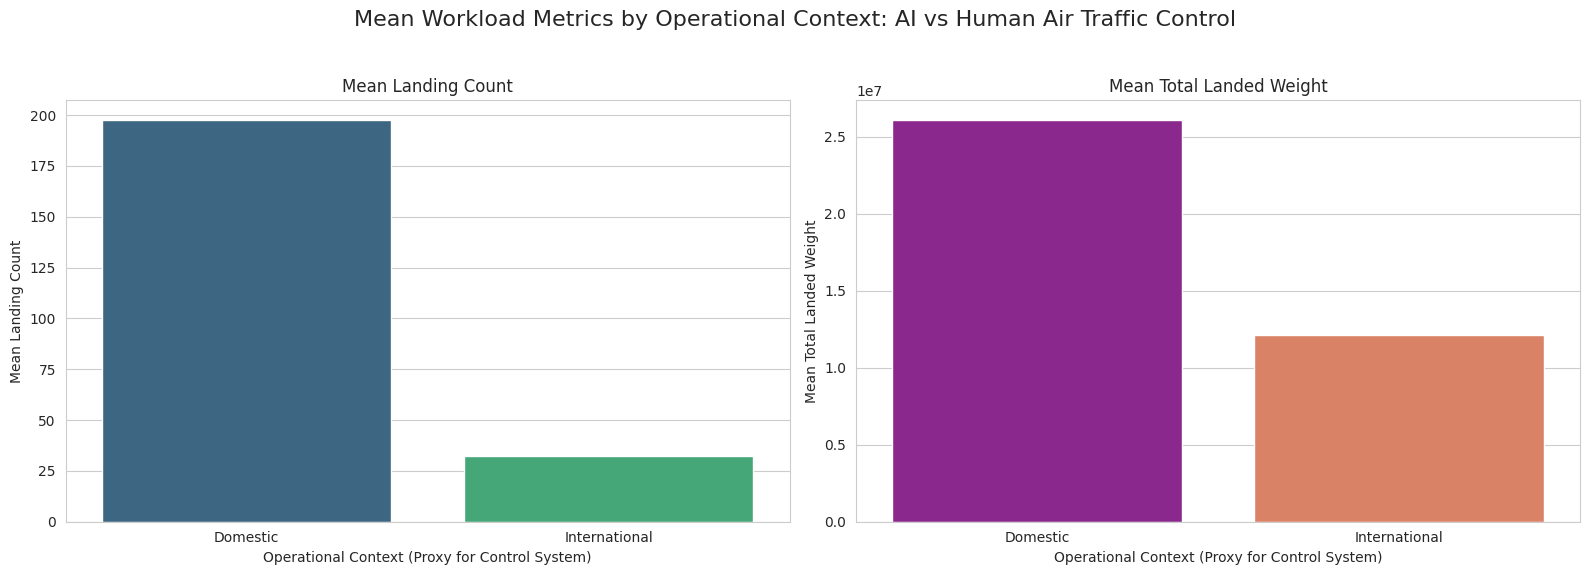

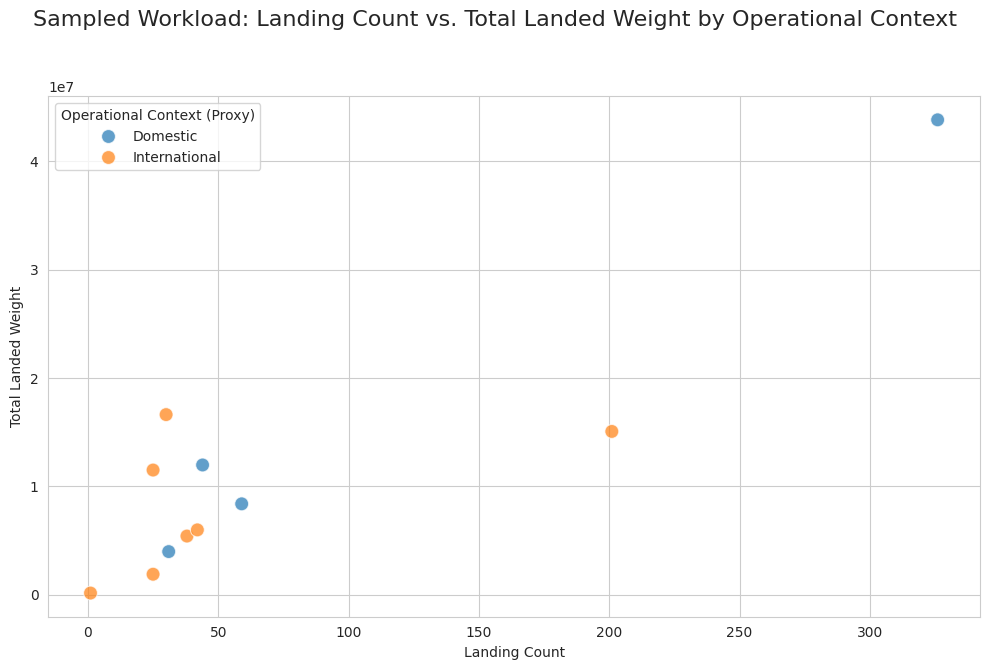

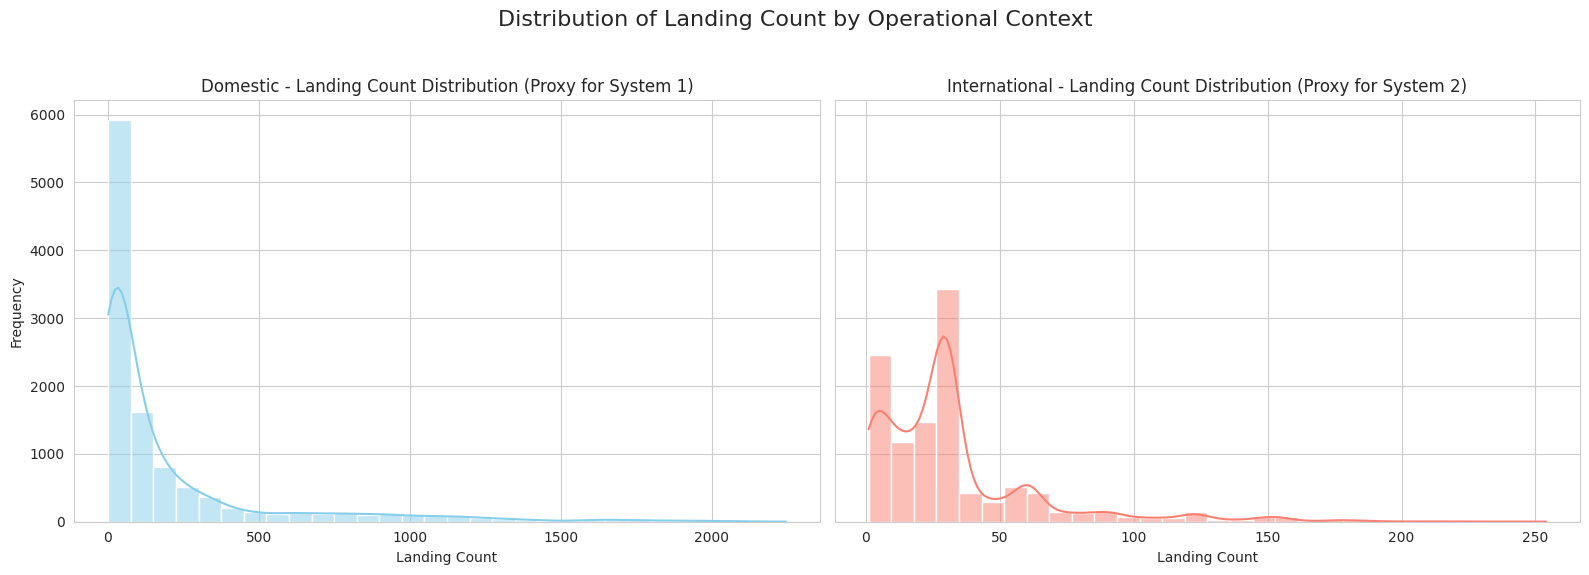

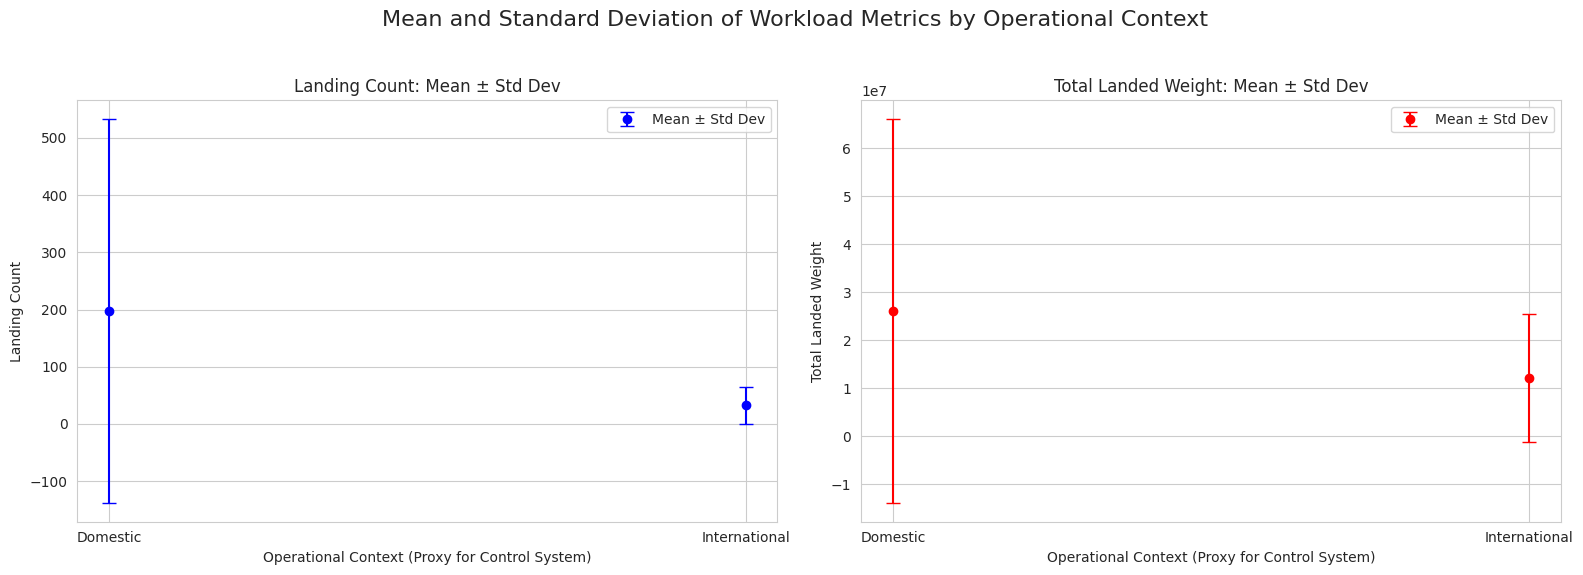

In [53]:
# --- Bar chart comparing mean workload between systems (proxy) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mean Workload Metrics by Operational Context: AI vs Human Air Traffic Control', fontsize=16)

# Mean Landing Count
sns.barplot(x=comparison_metrics.index, y=comparison_metrics[('Landing Count', 'mean')], ax=axes[0], palette='viridis')
axes[0].set_title('Mean Landing Count')
axes[0].set_xlabel('Operational Context (Proxy for Control System)')
axes[0].set_ylabel('Mean Landing Count')

# Mean Total Landed Weight
sns.barplot(x=comparison_metrics.index, y=comparison_metrics[('Total Landed Weight', 'mean')], ax=axes[1], palette='plasma')
axes[1].set_title('Mean Total Landed Weight')
axes[1].set_xlabel('Operational Context (Proxy for Control System)')
axes[1].set_ylabel('Mean Total Landed Weight')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Line plot for sampled data comparison (using scatter for clarity) ---
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Sampled Workload: Landing Count vs. Total Landed Weight by Operational Context', fontsize=16)
sns.scatterplot(data=df_sampled, x='Landing Count', y='Total Landed Weight', hue=grouping_column, s=100, alpha=0.7, ax=ax)
ax.set_xlabel('Landing Count')
ax.set_ylabel('Total Landed Weight')
ax.legend(title='Operational Context (Proxy)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Histogram comparing distributions (Landing Count) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Distribution of Landing Count by Operational Context', fontsize=16)

# Histogram for 'Domestic' GEO Summary
sns.histplot(df[df[grouping_column] == 'Domestic']['Landing Count'], kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title('Domestic - Landing Count Distribution (Proxy for System 1)')
axes[0].set_xlabel('Landing Count')
axes[0].set_ylabel('Frequency')

# Histogram for 'International' GEO Summary
sns.histplot(df[df[grouping_column] == 'International']['Landing Count'], kde=True, ax=axes[1], color='salmon', bins=30)
axes[1].set_title('International - Landing Count Distribution (Proxy for System 2)')
axes[1].set_xlabel('Landing Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Error bar plot (mean ± standard deviation) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mean and Standard Deviation of Workload Metrics by Operational Context', fontsize=16)

# Error bar for Landing Count
axes[0].errorbar(x=comparison_metrics.index, y=comparison_metrics[('Landing Count', 'mean')], yerr=comparison_metrics[('Landing Count', 'std')], capsize=5, fmt='o', color='blue', label='Mean ± Std Dev')
axes[0].set_title('Landing Count: Mean ± Std Dev')
axes[0].set_xlabel('Operational Context (Proxy for Control System)')
axes[0].set_ylabel('Landing Count')
axes[0].set_xticks(range(len(comparison_metrics.index)))
axes[0].set_xticklabels(comparison_metrics.index)
axes[0].legend()

# Error bar for Total Landed Weight
axes[1].errorbar(x=comparison_metrics.index, y=comparison_metrics[('Total Landed Weight', 'mean')], yerr=comparison_metrics[('Total Landed Weight', 'std')], capsize=5, fmt='o', color='red', label='Mean ± Std Dev')
axes[1].set_title('Total Landed Weight: Mean ± Std Dev')
axes[1].set_xlabel('Operational Context (Proxy for Control System)')
axes[1].set_ylabel('Total Landed Weight')
axes[1].set_xticks(range(len(comparison_metrics.index)))
axes[1].set_xticklabels(comparison_metrics.index)
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()